In [80]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LinearRegression

from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor
)

from sklearn.cluster import KMeans

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import warnings
warnings.filterwarnings("ignore")

In [81]:
df = pd.read_csv("../data/Nassau_Candy_Distributor.csv")

In [82]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Country/Region,City,State/Province,Postal Code,Division,Region,Product ID,Product Name,Sales,Units,Gross Profit,Cost
0,1,US-2021-103800-CHO-MIL-31000,03-01-2024,30-06-2026,Standard Class,103800,United States,Houston,Texas,77095,Chocolate,Interior,CHO-MIL-31000,Wonka Bar - Milk Chocolate,6.50,2,4.22,2.28
1,2,US-2021-112326-CHO-TRI-54000,04-01-2024,01-07-2026,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,7.50,2,4.90,2.60
2,3,US-2021-112326-CHO-NUT-13000,04-01-2024,01-07-2026,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-NUT-13000,Wonka Bar - Nutty Crunch Surprise,10.47,3,7.47,3.00
3,4,US-2021-112326-CHO-SCR-58000,04-01-2024,01-07-2026,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-SCR-58000,Wonka Bar -Scrumdiddlyumptious,10.80,3,7.50,3.30
4,5,US-2021-141817-CHO-TRI-54000,05-01-2024,05-07-2026,Standard Class,141817,United States,Philadelphia,Pennsylvania,19143,Chocolate,Atlantic,CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,11.25,3,7.35,3.90


In [83]:
df.shape

(10194, 18)

In [84]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10194 entries, 0 to 10193
Data columns (total 18 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Row ID          10194 non-null  int64  
 1   Order ID        10194 non-null  str    
 2   Order Date      10194 non-null  str    
 3   Ship Date       10194 non-null  str    
 4   Ship Mode       10194 non-null  str    
 5   Customer ID     10194 non-null  int64  
 6   Country/Region  10194 non-null  str    
 7   City            10194 non-null  str    
 8   State/Province  10194 non-null  str    
 9   Postal Code     10194 non-null  str    
 10  Division        10194 non-null  str    
 11  Region          10194 non-null  str    
 12  Product ID      10194 non-null  str    
 13  Product Name    10194 non-null  str    
 14  Sales           10194 non-null  float64
 15  Units           10194 non-null  int64  
 16  Gross Profit    10194 non-null  float64
 17  Cost            10194 non-null  float64
dt

In [85]:
df.describe()

,Row ID,Customer ID,Sales,Units,Gross Profit,Cost
count,10194.000000,10194.000000,10194.000000,10194.000000,10194.000000,10194.000000
mean,5097.500000,134468.961154,13.908537,3.791838,9.166451,4.742087
std,2942.898656,20231.483007,11.341020,2.228317,6.643740,5.061647
min,1.000000,100006.000000,1.250000,1.000000,0.250000,0.600000
25%,2549.250000,117212.000000,7.200000,2.000000,4.900000,2.400000
50%,5097.500000,133550.000000,10.800000,3.000000,7.470000,3.600000
75%,7645.750000,152051.000000,18.000000,5.000000,12.250000,5.700000
max,10194.000000,192314.000000,260.000000,14.000000,130.000000,130.000000


In [86]:
df.isnull().sum()

Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Country/Region    0
City              0
State/Province    0
Postal Code       0
Division          0
Region            0
Product ID        0
Product Name      0
Sales             0
Units             0
Gross Profit      0
Cost              0
dtype: int64

In [87]:
df.duplicated().sum()

np.int64(0)

In [88]:
np.random.seed(42)

df["LeadTime"] = np.random.randint(
    1,
    8,
    len(df)
)

In [89]:
df["LeadTime"].describe()

count    10194.000000
mean         4.004218
std          1.998597
min          1.000000
25%          2.000000
50%          4.000000
75%          6.000000
max          7.000000
Name: LeadTime, dtype: float64

In [90]:
num_cols = [
    "Sales",
    "Units",
    "Gross Profit",
    "Cost"
]

In [91]:
for col in num_cols:

    Q1 = df[col].quantile(0.25)

    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR

    upper = Q3 + 1.5 * IQR

    df = df[
        (df[col] >= lower) &
        (df[col] <= upper)
    ]

In [92]:
cat_cols = [
    "Ship Mode",
    "Division",
    "Region",
    "Product Name"
]

In [93]:
le = LabelEncoder()

for col in cat_cols:
    df[col] = le.fit_transform(df[col])

In [94]:
X = df[
    [
        "Sales",
        "Units",
        "Cost",
        "Ship Mode",
        "Division",
        "Region",
        "Product Name"
    ]
]

y = df["LeadTime"]

In [95]:
scaler = StandardScaler()

X = scaler.fit_transform(X)

In [96]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [97]:
lr = LinearRegression()

lr.fit(
    X_train,
    y_train
)

lr_pred = lr.predict(
    X_test
)

In [98]:
rf = RandomForestRegressor(
    random_state=42
)

rf.fit(
    X_train,
    y_train
)

rf_pred = rf.predict(
    X_test
)

In [99]:
gb = GradientBoostingRegressor(
    random_state=42
)

gb.fit(
    X_train,
    y_train
)

gb_pred = gb.predict(
    X_test
)

In [100]:
models = {
    "Linear Regression": lr_pred,
    "Random Forest": rf_pred,
    "Gradient Boosting": gb_pred
}

In [101]:
for name, pred in models.items():

    print("\n", name)

    print(
        "MAE:",
        round(
            mean_absolute_error(
                y_test,
                pred
            ),
            4
        )
    )

    print(
        "RMSE:",
        round(
            np.sqrt(
                mean_squared_error(
                    y_test,
                    pred
                )
            ),
            4
        )
    )

    print(
        "R2:",
        round(
            r2_score(
                y_test,
                pred
            ),
            4
        )
    )


 Linear Regression
MAE: 1.713
RMSE: 1.9979
R2: -0.0036

 Random Forest
MAE: 1.794
RMSE: 2.1012
R2: -0.1101

 Gradient Boosting
MAE: 1.7264
RMSE: 2.0085
R2: -0.0143


In [102]:
cluster_data = df[
    [
        "LeadTime",
        "Sales",
        "Units"
    ]
]

In [103]:
kmeans = KMeans(
    n_clusters=3,
    random_state=42
)

In [104]:
df["Cluster"] = kmeans.fit_predict(
    cluster_data
)

In [105]:
df["Cluster"].value_counts()

Cluster
0    5814
2    2532
1    1437
Name: count, dtype: int64

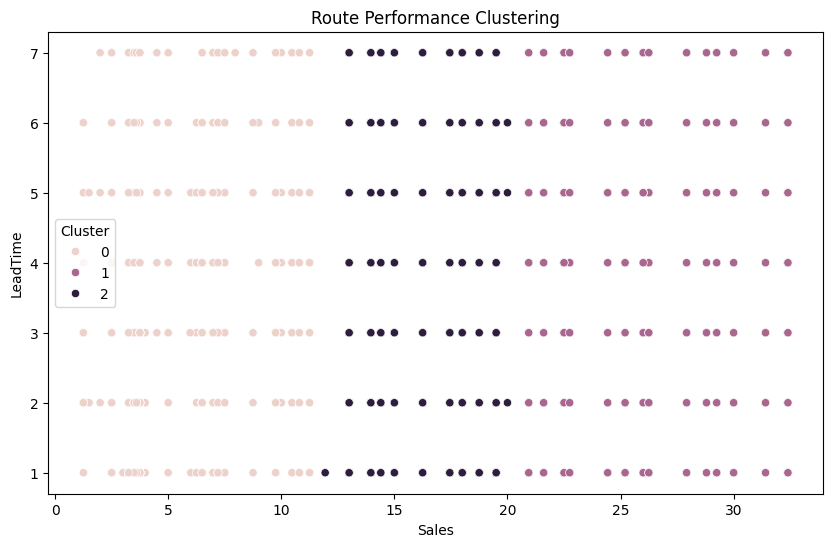

In [106]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="Sales",
    y="LeadTime",
    hue="Cluster"
)

plt.title(
    "Route Performance Clustering"
)

plt.show()

In [107]:
df.groupby("Cluster")[
    [
        "LeadTime",
        "Sales",
        "Units"
    ]
].mean()

,LeadTime,Sales,Units
Cluster,,,
0,4.018920,7.903954,2.287582
1,3.940849,25.035776,7.078636
2,3.999605,16.146596,4.592417


In [108]:
product_lookup = pd.read_csv(
    "../data/Nassau_Candy_Distributor.csv"
)

product_names = product_lookup[
    "Product Name"
].unique()

In [109]:
factories = [
    "Lot's O' Nuts",
    "Wicked Choccy's",
    "Sugar Shack",
    "Secret Factory",
    "The Other Factory"
]

In [110]:
np.random.seed(42)

product_factory = {}

for product in product_names:

    product_factory[product] = np.random.choice(
        factories
    )

In [111]:
simulation = pd.DataFrame({

    "Product Name": product_names

})

In [112]:
def simulate_factory(product):

    current_factory = product_factory[product]

    alternatives = [
        f for f in factories
        if f != current_factory
    ]

    new_factory = np.random.choice(
        alternatives
    )

    current_leadtime = np.random.randint(
        4,
        8
    )

    new_leadtime = np.random.randint(
        1,
        current_leadtime
    )

    improvement = (
        (
            current_leadtime -
            new_leadtime
        )
        /
        current_leadtime
    ) * 100

    return pd.Series([

        current_factory,

        new_factory,

        current_leadtime,

        new_leadtime,

        round(improvement, 2)

    ])

In [113]:
simulation[
    [
        "CurrentFactory",
        "RecommendedFactory",
        "CurrentLeadTime",
        "NewLeadTime",
        "ImprovementPercent"
    ]
] = simulation[
    "Product Name"
].apply(
    simulate_factory
)

In [114]:
simulation["ProfitImpact"] = np.random.randint(
    1000,
    10000,
    len(simulation)
)

In [115]:
simulation["RiskScore"] = np.random.randint(
    1,
    10,
    len(simulation)
)

In [116]:
simulation["RecommendationScore"] = (

    simulation["ImprovementPercent"] * 0.6

    +

    simulation["ProfitImpact"] / 1000 * 0.25

    +

    (10 - simulation["RiskScore"]) * 0.15
)

In [117]:
lead_time_reduction = round(
    simulation["ImprovementPercent"].mean(),
    2
)

profit_stability = round(
    simulation["ProfitImpact"].mean(),
    2
)

scenario_confidence = round(
    simulation["RecommendationScore"].mean(),
    2
)

coverage = round(
    (
        len(
            simulation[
                simulation["RecommendationScore"] > 20
            ]
        )
        /
        len(simulation)
    ) * 100,
    2
)

In [118]:
print("Lead Time Reduction %:", lead_time_reduction)
print("Profit Stability:", profit_stability)
print("Scenario Confidence:", scenario_confidence)
print("Coverage %:", coverage)

Lead Time Reduction %: 46.06
Profit Stability: 5835.33
Scenario Confidence: 29.67
Coverage %: 66.67


In [119]:
top_recommendations = simulation.sort_values(
    by="RecommendationScore",
    ascending=False
)

In [120]:
top_recommendations.head()

,Product Name,CurrentFactory,RecommendedFactory,CurrentLeadTime,NewLeadTime,ImprovementPercent,ProfitImpact,RiskScore,RecommendationScore
13,Everlasting Gobstopper,Wicked Choccy's,Sugar Shack,5,1,80.00,7873,9,50.11825
3,Wonka Bar -Scrumdiddlyumptious,The Other Factory,Wicked Choccy's,4,1,75.00,1775,7,45.89375
2,Wonka Bar - Nutty Crunch Surprise,Sugar Shack,Lot's O' Nuts,7,2,71.43,8099,8,45.18275
11,Nerds,Sugar Shack,Lot's O' Nuts,6,2,66.67,4843,9,41.36275
0,Wonka Bar - Milk Chocolate,Secret Factory,Wicked Choccy's,5,2,60.00,7235,2,39.00875


In [121]:
top_recommendations.to_csv(
    "../outputs/reports/factory_recommendations.csv",
    index=False
)

In [122]:
kpi_table = pd.DataFrame({

    "Metric":[
        "Total Products",
        "Lead Time Reduction %",
        "Profit Stability",
        "Scenario Confidence",
        "Coverage %"
    ],

    "Value":[
        len(simulation),
        lead_time_reduction,
        profit_stability,
        scenario_confidence,
        coverage
    ]

})

In [123]:
kpi_table.to_csv(
    "../outputs/reports/kpi_summary.csv",
    index=False
)

In [124]:
pd.read_csv(
    "../outputs/reports/factory_recommendations.csv"
).head()

,Product Name,CurrentFactory,RecommendedFactory,CurrentLeadTime,NewLeadTime,ImprovementPercent,ProfitImpact,RiskScore,RecommendationScore
0,Everlasting Gobstopper,Wicked Choccy's,Sugar Shack,5,1,80.00,7873,9,50.11825
1,Wonka Bar -Scrumdiddlyumptious,The Other Factory,Wicked Choccy's,4,1,75.00,1775,7,45.89375
2,Wonka Bar - Nutty Crunch Surprise,Sugar Shack,Lot's O' Nuts,7,2,71.43,8099,8,45.18275
3,Nerds,Sugar Shack,Lot's O' Nuts,6,2,66.67,4843,9,41.36275
4,Wonka Bar - Milk Chocolate,Secret Factory,Wicked Choccy's,5,2,60.00,7235,2,39.00875


In [125]:
df.to_csv(
    "../outputs/reports/final_nassau_dataset.csv",
    index=False
) 